### Setting

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import os
import pandas as pd

import torch
import torch.nn as nn

#import gensim
#from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

import re
import numpy as np

from sklearn.preprocessing import LabelEncoder

import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from collections import Counter

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available!")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

GPU not available, using CPU.


# Data Loader

In [ ]:
cd /content/gdrive/MyDrive/Master degree/25T1/Dataset

/content/gdrive/MyDrive/Master degree/25T1/Dataset


In [ ]:
I_plus_train = pd.read_parquet("I_plus_train.parquet")
I_minus_train = pd.read_parquet("I_minus_train.parquet")
I_plus_val = pd.read_parquet("I_plus_val.parquet")
I_minus_val = pd.read_parquet("I_minus_val.parquet")
test = pd.read_parquet("test.parquet")

In [ ]:
# Fit the scaler on the training data
scaler = StandardScaler()
scaler.fit(I_plus_train[['energy', 'key', 'loudness', 'mode', 'speechiness',
                         'acousticness', 'instrumentalness', 'liveness',
                         'valence', 'tempo']])

# Transform the data and replace the original columns with standardized values
I_plus_train[['energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness',
              'valence', 'tempo']] = scaler.transform(I_plus_train[['energy', 'key',
                                                                     'loudness', 'mode',
                                                                     'speechiness', 'acousticness',
                                                                     'instrumentalness', 'liveness',
                                                                     'valence', 'tempo']])

scaler.fit(I_minus_train[['energy', 'key', 'loudness', 'mode', 'speechiness',
                         'acousticness', 'instrumentalness', 'liveness',
                         'valence', 'tempo']])

# Transform the data and replace the original columns with standardized values
I_minus_train[['energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness',
              'valence', 'tempo']] = scaler.transform(I_minus_train[['energy', 'key',
                                                                     'loudness', 'mode',
                                                                     'speechiness', 'acousticness',
                                                                     'instrumentalness', 'liveness',
                                                                     'valence', 'tempo']])

#I_plus_train.iloc[:,6:16]

In [ ]:
# Fit the scaler on the training data
scaler.fit(I_plus_val[['energy', 'key', 'loudness', 'mode', 'speechiness',
                         'acousticness', 'instrumentalness', 'liveness',
                         'valence', 'tempo']])

# Transform the data and replace the original columns with standardized values
I_plus_val[['energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness',
              'valence', 'tempo']] = scaler.transform(I_plus_val[['energy', 'key',
                                                                     'loudness', 'mode',
                                                                     'speechiness', 'acousticness',
                                                                     'instrumentalness', 'liveness',
                                                                     'valence', 'tempo']])

scaler.fit(I_minus_val[['energy', 'key', 'loudness', 'mode', 'speechiness',
                         'acousticness', 'instrumentalness', 'liveness',
                         'valence', 'tempo']])

# Transform the data and replace the original columns with standardized values
I_minus_val[['energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness',
              'valence', 'tempo']] = scaler.transform(I_minus_val[['energy', 'key',
                                                                     'loudness', 'mode',
                                                                     'speechiness', 'acousticness',
                                                                     'instrumentalness', 'liveness',
                                                                     'valence', 'tempo']])


In [ ]:
I_plus_train

,pid,track_id,track_name,album_name,artist_name,danceability,energy,key,loudness,mode,...,lemmatized_album_name,track_sentences,album_sentences,artist_id,audio_features,track_embeddings,album_embeddings,new_pid,album_Bert_embedding,track_Bert_embedding
0,3,39055,Just Get High,Die Alone,Gazebos,0.337,0.230305,1.074302,0.056659,0.706732,...,die alone,"[get, high]","[die, alone]",7899,"[0.337, 0.701, 9.0, -6.974, 1.0, 0.0306, 0.001...","[[0.033203125, -0.08984375, -0.294921875, 0.11...","[[0.10009765625, 0.17578125, 0.043701171875, 0...",0,"[0.020719705, 0.25220913, -0.15911399, 0.18181...","[0.20254193, 0.32272324, -0.08004451, 0.049623..."
1,3,52439,Nothing's Gonna Hurt You Baby,I.,Cigarettes After Sex,0.509,-1.544450,-0.312059,-1.930558,0.706732,...,i,"[nothing, gonna, hurt, baby]",[i],4150,"[0.509, 0.331, 4.0, -14.083, 1.0, 0.0267, 0.27...","[[0.1640625, 0.056396484375, 0.08251953125, -0...","[[-0.2255859375, -0.01953125, 0.0908203125, 0....",0,"[-0.5305576, 0.11689519, -0.14607719, -0.25065...","[0.29745492, 0.15301126, -0.12392438, 0.069712..."
2,3,33924,I Like You,It's All In Your Head,dandelion hands,0.350,-2.652472,-0.312059,-3.162750,0.706732,...,head,[like],[head],24118,"[0.35, 0.1, 4.0, -18.491, 1.0, 0.0328, 0.989, ...","[[0.103515625, 0.1376953125, -0.00297546386718...","[[-0.0712890625, -0.07373046875, 0.19921875, -...",0,"[0.14113334, 0.32188103, 0.04410696, 0.1082610...","[0.015903875, 0.0660543, -0.09751289, 0.076490..."
3,3,15639,Crystal,Candy Apple Grey,Hüsker Dü,0.386,1.491819,0.519758,-1.155407,0.706732,...,candy apple grey,[crystal],"[candy, apple, grey]",9198,"[0.386, 0.964, 7.0, -11.31, 1.0, 0.076, 0.0589...","[[0.045654296875, -0.26953125, 0.0732421875, -...","[[-0.050048828125, -0.232421875, -0.0308837890...",0,"[-0.20137045, -0.049502436, -0.59205437, -0.02...","[-0.16305159, 0.15954661, 0.0659531, -0.022099..."
4,3,85903,You Say I'm in Love,You Say I'm in Love,Banes World,0.625,-1.765095,-1.143875,-2.658189,-1.414964,...,say im love,"[say, im, love]","[say, im, love]",1905,"[0.625, 0.285, 1.0, -16.686, 0.0, 0.0537, 0.43...","[[-0.0361328125, -0.12109375, 0.1337890625, 0....","[[-0.0361328125, -0.12109375, 0.1337890625, 0....",0,"[0.16846092, 0.17492926, -0.4919998, 0.0336023...","[0.16846092, 0.17492926, -0.4919998, 0.0336023..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7065,453,36170,If You're Gone,Mad Season,Matchbox Twenty,0.544,0.028846,1.074302,-0.004000,0.706732,...,mad season,"[youre, go]","[mad, season]",13932,"[0.544, 0.659, 9.0, -7.191, 1.0, 0.0298, 0.427...","[[0.28125, 0.033447265625, -0.035888671875, 0....","[[0.055419921875, -0.056640625, 0.150390625, 0...",100,"[-0.32580608, -0.16754074, -0.0823893, -0.0792...","[0.09254932, 0.23144999, -0.05158483, -0.12181..."
7066,453,6723,Barely Breathing,Duncan Sheik,Duncan Sheik,0.482,0.738748,-1.421147,0.056100,0.706732,...,duncan sheik,"[barely, breathing]","[duncan, sheik]",6250,"[0.482, 0.807, 0.0, -6.976, 1.0, 0.0457, 0.028...","[[0.2021484375, -0.25390625, -0.035400390625, ...","[[-0.06005859375, 0.1591796875, 0.019287109375...",100,"[-0.4858875, 0.24359304, -0.49777362, 0.172126...","[-0.34052244, 0.19653437, -0.12518123, -0.3739..."
7067,453,45970,Making Love Out of Nothing at All,The Best of Air Supply: Ones That You Love,Air Supply,0.386,0.230305,0.519758,0.330883,0.706732,...,best air supply one love,"[make, love, nothing]","[best, air, supply, one, love]",574,"[0.386, 0.701, 7.0, -5.993, 1.0, 0.0332, 0.14,...","[[-0.11328125, -0.036865234375, 0.09423828125,...","[[-0.126953125, 0.02197265625, 0.287109375, 0....",100,"[-0.1786602, 0.08967763, -0.31454346, 0.160023...","[-0.57437235, -0.37043536, -0.31799096, 0.5702..."
7068,453,32266,How Deep Is Your Love,Greatest,Bee Gees,0.633,-1.419737,-0.034786,-0.611990,-1.414964,...,great,"[deep, love]",[great],2071,"[0.633, 0.357, 5.0, -9.366, 0.0, 0.0264, 0.105...","[[-0.0361328125, 0.1494140625, 0.1376953125, 0...","[[0.07177734375, 0.2080078125, -0

In [ ]:
class MusicDataset(Dataset):
    def __init__(self, I_plus, I_minus):
        self.I_plus = I_plus
        self.I_minus = I_minus

    def __len__(self):
        return len(self.I_plus)

    def __getitem__(self, idx):
        I_plus_batch = self.I_plus.iloc[idx]
        I_minus_batch = self.I_minus.iloc[idx]


        I_plus_batch_tensor = {
            'pid': torch.tensor(I_plus_batch['new_pid'], dtype=torch.long),
            #'artist_id': torch.tensor(I_plus_batch['artist_id'], dtype=torch.long),
            'track_embeddings': torch.tensor(I_plus_batch['track_Bert_embedding'], dtype=torch.float32),
            'album_embeddings': torch.tensor(np.array(I_plus_batch['album_Bert_embedding']), dtype=torch.float32),
            'audio_features': torch.tensor(I_plus_batch['audio_features'], dtype=torch.float32)
        }

        I_minus_batch_tensor = {
            'pid': torch.tensor(I_minus_batch['new_pid'], dtype=torch.long),
            #'artist_id': torch.tensor(I_plus_batch['artist_id'], dtype=torch.long),
            'track_embeddings': torch.tensor(I_minus_batch['track_Bert_embedding'], dtype=torch.float32),
            'album_embeddings': torch.tensor(np.array(I_minus_batch['album_Bert_embedding']), dtype=torch.float32),
            'audio_features': torch.tensor(I_minus_batch['audio_features'], dtype=torch.float32)
        }

        return I_plus_batch_tensor, I_minus_batch_tensor


In [ ]:
trainSize = 70
valSize = 15

In [ ]:
# Create the Dataset
train_dataset = MusicDataset(I_plus_train, I_minus_train)
# Create the DataLoader
train_loader = DataLoader(train_dataset, batch_size=trainSize, shuffle=False)  # Modify batch size as needed

# Create the Dataset
val_dataset = MusicDataset(I_plus_val, I_minus_val)
# Create the DataLoader
val_loader = DataLoader(val_dataset, batch_size=valSize, shuffle=False)  # Modify batch size as needed

# Modelling

#### Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, embedding_dim=768, hidden_dim=256, bottleneck_dim=128):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


In [ ]:
class Album_Autoencoder(nn.Module):
    def __init__(self, embedding_dim=768, hidden_dim1=512, hidden_dim2=256, bottleneck_dim=128):
        super(Album_Autoencoder, self).__init__()

        # Encoder: 768 → 512 → 256 → 128
        self.encoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim1),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim1),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim2),

            nn.Linear(hidden_dim2, bottleneck_dim)
        )

        # Decoder: 128 → 256 → 512 → 768
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim2),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim2),

            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim1),

            nn.Linear(hidden_dim1, embedding_dim)
        )

    def forward(self, x):
        z = self.encoder(x)       # Bottleneck representation (128)
        x_hat = self.decoder(z)   # Reconstructed 768-dim vector
        return x_hat, z


#### Album Embedding

In [ ]:
class Album_Embedding(nn.Module):
    def __init__(self):
        super(Album_Embedding, self).__init__()
        #self.autoencoder = Autoencoder()
        self.autoencoder = Album_Autoencoder()

    def forward(self, album_BERT):
        _, compressed = self.autoencoder(album_BERT)
        return compressed  # Shape: (batch, 128)

#### Track Embedding

In [ ]:
class Track_Embedding(nn.Module):
    def __init__(self):
        super(Track_Embedding, self).__init__()
        self.autoencoder = Autoencoder()

    def forward(self, track_BERT):
        _, compressed = self.autoencoder(track_BERT)
        return compressed  # Shape: (batch, 128)

#### Artist Embedding

In [ ]:
# class Artist_Embedding(nn.Module):
#     def __init__(self, num_artists, input_dim, hidden_dim, output_dim):
#         super(Artist_Embedding, self).__init__()
#         self.artist_embedding = nn.Embedding(num_artists, input_dim)  # Artist Embedding lookup
#         self.autoencoder = AutoEncoder(input_dim, hidden_dim, output_dim)

#     def forward(self, artist_ids):
#         artist_embeds = self.artist_embedding(artist_ids)  # Shape: (batch_size, input_dim)
#         #artist_embeds = self.artist_embedding(artist_ids).squeeze(1)  # Adjust shape here if necessary
#         artist_embeds_reduced, reconstruction = self.autoencoder(artist_embeds)  # Compress using autoencoder
#         return artist_embeds_reduced, reconstruction

In [ ]:
#Temporal
# class Artist_Embedding(nn.Module):
#     def __init__(self, num_artists, embedding_dim=300, reduced_dim = 100):
#         super(Artist_Embedding, self).__init__()

#         self.embedding = nn.Embedding(num_artists , embedding_dim)
#         self.fc = nn.Linear(embedding_dim, reduced_dim)

#     def forward(self, artist_ids):
#         artist_embeds = self.embedding(artist_ids)
#         artist_embeds_reduced = self.fc(artist_embeds)

#         return artist_embeds_reduced

### Audio Embedding


In [ ]:
#BEST AUDIO ONLY
class Audio_Embedding(nn.Module):
    def __init__(self, embedding_dim=11, unified_dim=128):
        super(Audio_Embedding, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.GELU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, unified_dim),
            nn.GELU(),
            nn.BatchNorm1d(unified_dim)
        )

    def forward(self, audio_features):
        audio_embeds_unified = self.fc(audio_features)  # shape: (batch_size, 128)
        return audio_embeds_unified


#### Item Embedding

In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super(CrossAttention, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value):
        attn_output, _ = self.attn(query, key, value)
        return self.norm(query + self.dropout(attn_output))

In [ ]:
# === Cross-Attention-Based Fusion (Takes embeddings as input) ===
class MultiFeatureCrossAttentionModel(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, out_dim=128):
        super(MultiFeatureCrossAttentionModel, self).__init__()

        self.cross_attn_album_track = CrossAttention(embed_dim, num_heads)
        self.cross_attn_audio_album_track = CrossAttention(embed_dim, num_heads)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim)
        )

    def forward(self, audio_embed, album_embed, track_embed):
        album_track_attended = self.cross_attn_album_track(album_embed, track_embed, track_embed)
        audio_album_track_attended = self.cross_attn_audio_album_track(audio_embed, album_track_attended, album_track_attended)
        return self.mlp(audio_album_track_attended)  # Final item embedding


#audio track album

#audio and track - cross ateention /
# 2% -> 20%
# introduction, methodology introduction part (techniques) ->  Main chapter to result/ no need any reference.
# Result each technique
# structure sample (follow) /


In [ ]:
class Item_Embedding(nn.Module):
    def __init__(self, audio_embedding, album_embedding, track_embedding, cross_attention_model):
        super(Item_Embedding, self).__init__()
        self.audio_embedding = audio_embedding
        self.album_embedding = album_embedding
        self.track_embedding = track_embedding
        self.cross_attn = cross_attention_model

    def forward(self, audio_features, album_features, track_features):
        audio_embed = self.audio_embedding(audio_features)
        album_embed = self.album_embedding(album_features)
        track_embed = self.track_embedding(track_features)

        return self.cross_attn(audio_embed, album_embed, track_embed)

#### User Embedding

Over time, the user embedding should learn to represent the user’s preferences based on how often the user interacts with certain items.
This is because the model updates the user embedding based on the similarities between the user embedding and the item embeddings (which are influenced by item features).

In [ ]:
class User_Embedding(nn.Module):
    def __init__(self, num_playlists, embedding_dim=300, reduced_dim=128):
        super(User_Embedding, self).__init__()

        self.user_embedding = nn.Embedding(num_playlists, embedding_dim)


        self.fc = nn.Sequential(
          nn.Linear(embedding_dim,250),
          nn.ReLU(),
          nn.Linear(250, 200),
          nn.ReLU(),
          nn.Linear(200, 150),
          nn.ReLU(),
          nn.Linear(150, reduced_dim),
          nn.ReLU()
    )

        # Fully connected layer to reduce dimensionality to 128
        self.fc = nn.Linear(embedding_dim, reduced_dim)

    def forward(self, playlist_ids):
        user_embeds = self.user_embedding(playlist_ids)  # Shape: (batch_size, embedding_dim)
        user_embeds_reduced = self.fc(user_embeds)
        # Shape: (batch_size, reduced_dim]
        return user_embeds_reduced

#### User Item Embedding

In [ ]:
class UserItemEmbedding(nn.Module):
    def __init__(self, user_embedding_model, item_embedding_model):
        super(UserItemEmbedding, self).__init__()
        self.user_embedding = user_embedding_model
        self.item_embedding = item_embedding_model

    def forward(self, playlist_ids, audio_features, album_features, track_features):
        # Get user embeddings using playlist IDs
        user_embeds = self.user_embedding(playlist_ids)

        # Get item embeddings using all input features
        item_embeds = self.item_embedding(audio_features, album_features, track_features)
        return user_embeds, item_embeds

#### Model Initialisation

In [ ]:
# === Model Initialization ===
num_playlists = 101
embedding_dim = 128
reduced_dim = 128

audio_embedding_model = Audio_Embedding(embedding_dim=11, unified_dim=embedding_dim)
album_embedding_model = Album_Embedding()
track_embedding_model = Track_Embedding()

cross_attention_model = MultiFeatureCrossAttentionModel(
    embed_dim=embedding_dim,
    out_dim=reduced_dim
)

item_embedding_model = Item_Embedding(
    audio_embedding=audio_embedding_model,
    album_embedding=album_embedding_model,
    track_embedding=track_embedding_model,
    cross_attention_model=cross_attention_model
)

user_embedding_model = User_Embedding(
    num_playlists=num_playlists,
    embedding_dim=300,
    reduced_dim=reduced_dim
)

user_item_model = UserItemEmbedding(
    user_embedding_model=user_embedding_model,
    item_embedding_model=item_embedding_model
)


# Training

### Hyperparameters and Loss function

In [ ]:
class MaxMarginLoss(nn.Module):
    def __init__(self, margin):
        super(MaxMarginLoss, self).__init__()
        self.margin = margin

    def forward(self, user_embed, item_embed_pos, item_embed_neg):
        # # Calculate cosine similarities
        # pos_similarity = torch.cosine_similarity(user_embed, item_embed_pos)
        # neg_similarity = torch.cosine_similarity(user_embed, item_embed_neg)

        vx_pos = item_embed_pos - torch.mean(item_embed_pos)
        vx_neg = item_embed_neg - torch.mean(item_embed_neg)

        vy = user_embed - torch.mean(user_embed)

        # Pearson Similarity
        pos_similarity = torch.sum(vx_pos * vy) / (torch.sqrt(torch.sum(vx_pos ** 2)) * torch.sqrt(torch.sum(vy ** 2)))
        neg_similarity = torch.sum(vx_neg * vy) / (torch.sqrt(torch.sum(vx_neg ** 2)) * torch.sqrt(torch.sum(vy ** 2)))

        # Ensure margin is on the correct device
        margin_tensor = torch.tensor(self.margin, device=pos_similarity.device)


        # Max-margin hinge loss
        # Changed from 0 to torch.tensor(0., device=pos_similarity.device)
        loss = torch.max(torch.tensor(0., device=pos_similarity.device), margin_tensor - pos_similarity + neg_similarity)

        return loss

### Training

##### Validation function

In [ ]:
def validate(model, val_loader, loss_fn, recon_loss_fn):
    model.eval()
    loss_val = 0.0

    # Optional: 추적용 loss들
    max_margin_loss = 0.0
    Track_recon_loss = 0.0
    Album_recon_loss = 0.0

    with torch.no_grad():
        for I_plus_batch, I_minus_batch in val_loader:

            # Move all tensors to device
            I_plus_batch = {key: value.to(device) for key, value in I_plus_batch.items()}
            I_minus_batch = {key: value.to(device) for key, value in I_minus_batch.items()}

            # === Positive samples ===
            user_embeds_pos = model.user_embedding(I_plus_batch['pid'])
            item_embeds_pos = model.item_embedding(
                audio_features=I_plus_batch['audio_features'],
                album_features=I_plus_batch['album_embeddings'],
                track_features=I_plus_batch['track_embeddings']
            )

            # === Negative samples ===
            item_embeds_neg = model.item_embedding(
                audio_features=I_minus_batch['audio_features'],
                album_features=I_minus_batch['album_embeddings'],
                track_features=I_minus_batch['track_embeddings']
            )

            # === Max-margin loss ===
            loss = loss_fn(user_embeds_pos, item_embeds_pos, item_embeds_neg)
            max_margin_loss += loss

            # === Final loss (e.g., reconstruction loss도 더하고 싶다면 여기에 추가 가능) ===
            total_loss = loss
            loss_val += total_loss.item()

    return loss_val / len(val_loader), max_margin_loss / len(val_loader)


In [ ]:
# def validate(model, val_loader, loss_fn, recon_loss_fn):
#     model.eval()  # Set model to evaluation mode
#     loss_val = 0.0


#     ##########ADDEDE#########
#     max_margin_loss = 0.0
#     Track_recon_loss = 0.0
#     Album_recon_loss = 0.0
#     ##########################

#     with torch.no_grad():  # No need to track gradients for validation
#         for I_plus_batch, I_minus_batch in val_loader:

#             # Assign GPU

#             I_plus_batch = {key: value.to(device) for key, value in I_plus_batch.items()}
#             I_minus_batch = {key: value.to(device) for key, value in I_minus_batch.items()}


#             # Extract user and item embeddings for Positive samples
#             user_embeds_pos = model.user_embedding(I_plus_batch['pid'])
#             item_embeds_pos = model.item_embedding(
#                 I_plus_batch['audio_features']
#             )

#             # Negative Samples
#             item_embeds_neg = model.item_embedding(
#                 I_minus_batch['audio_features']
#             )

#             # Compute the max-margin loss
#             loss = loss_fn(user_embeds_pos, item_embeds_pos, item_embeds_neg)




#             #################ADDED############
#             max_margin_loss += loss

#             ######################################


#             # Total loss = max-margin loss + reconstruction losses
#             total_loss = loss

#             # Accumulate validation loss
#             loss_val += total_loss.item()


#     return loss_val / len(val_loader), max_margin_loss/len(val_loader)

##### Training Function

In [ ]:
music_pool = test
scaler = StandardScaler()
scaler.fit(music_pool[['energy', 'key', 'loudness', 'mode', 'speechiness',
                         'acousticness', 'instrumentalness', 'liveness',
                         'valence', 'tempo']])

music_pool[['energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness',
              'valence', 'tempo']] = scaler.transform(music_pool[['energy', 'key',
                                                                     'loudness', 'mode',
                                                                     'speechiness', 'acousticness',
                                                                     'instrumentalness', 'liveness',
                                                                     'valence', 'tempo']])

#Re-Assign the TrackID
unique_track_ids = music_pool['track_id'].unique()
track_id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_track_ids)}
music_pool['new_track_id'] = music_pool['track_id'].map(track_id_mapping)
test['new_track_id'] = test['track_id'].map(track_id_mapping)



class MusicPoolDataset(Dataset):
    def __init__(self, I_plus):
        self.I_plus = I_plus


    def __len__(self):
        return len(self.I_plus)

    def __getitem__(self, idx):
        I_plus_batch = self.I_plus.iloc[idx]


        I_plus_batch_tensor = {
            #'pid': torch.tensor(I_plus_batch['new_pid'], dtype=torch.long),
            'track_id': torch.tensor(I_plus_batch['new_track_id'], dtype=torch.long),
            #'audio_features': torch.tensor(I_plus_batch['bert_embedding'], dtype=torch.float32),
            #'artist_id': torch.tensor(I_plus_batch['artist_id'], dtype=torch.long),
            'track_embeddings': torch.tensor(I_plus_batch['track_Bert_embedding'], dtype=torch.float32),
            'album_embeddings': torch.tensor(np.array(I_plus_batch['album_Bert_embedding']), dtype=torch.float32),
            'audio_features': torch.tensor(I_plus_batch['audio_features'], dtype=torch.float32)
        }

        return I_plus_batch_tensor

# Create the Dataset
music_pool_dataset = MusicPoolDataset(music_pool)
# Create the DataLoader
music_pool_loader = DataLoader(music_pool_dataset, batch_size=50, shuffle=False)  # Modify batch size as needed


In [ ]:
def calculate_item_embeddings(model, data_loader, device):
    all_item_embeddings = []
    all_track_ids = []

    model.eval()

    for batch_idx, I_plus_batch in enumerate(data_loader):
        # Move inputs to device
        audio_features = I_plus_batch['audio_features'].to(device)
        album_features = I_plus_batch['album_embeddings'].to(device)
        track_features = I_plus_batch['track_embeddings'].to(device)
        track_ids = I_plus_batch['track_id'].to(device)

        # Compute item embeddings using the full set of features
        item_embed = model.item_embedding(
            audio_features=audio_features,
            album_features=album_features,
            track_features=track_features
        )

        # Accumulate
        all_item_embeddings.append(item_embed)
        all_track_ids.append(track_ids)

    # Combine all batches
    all_item_embeddings = torch.cat(all_item_embeddings, dim=0).to(device)
    all_track_ids = torch.cat(all_track_ids, dim=0).to(device)

    return all_item_embeddings, all_track_ids


In [ ]:
def calculate_hit_ratio(model, all_user_embeddings, all_item_embeddings, track_ids, top_k):
  # Ensure embeddings are on the same device (CPU or GPU)
  all_user_embeddings = all_user_embeddings.to(all_item_embeddings.device)

  # Step 1: Center the embeddings by subtracting the mean
  user_means = all_user_embeddings.mean(dim=1, keepdim=True)
  item_means = all_item_embeddings.mean(dim=1, keepdim=True)

  all_user_embeddings_centered = all_user_embeddings - user_means
  all_item_embeddings_centered = all_item_embeddings - item_means

  # Step 2: Calculate the standard deviations
  user_std = all_user_embeddings_centered.std(dim=1, keepdim=True)
  item_std = all_item_embeddings_centered.std(dim=1, keepdim=True)

  # Step 3: Standardize the embeddings
  all_user_embeddings_standardized = all_user_embeddings_centered / user_std
  all_item_embeddings_standardized = all_item_embeddings_centered / item_std

  # Step 4: Compute Pearson correlation similarity
  # Reshape user embeddings for broadcasting (101, 30) -> (101, 1, 30)
  all_user_embeddings_standardized = all_user_embeddings_standardized.unsqueeze(1)

  # Calculate similarity: (101, 1, 30) * (1, 7602, 30) -> (101, 7602)
  #pearson_similarity = (all_user_embeddings_standardized * all_item_embeddings_standardized).sum(dim=2) / 30
  pearson_similarity = (all_user_embeddings_standardized * all_item_embeddings_standardized).sum(dim=2) / 128


  #top_k = 200
  top_k_tracks_ids = torch.topk(pearson_similarity, top_k, dim=1).indices

  # Count occurrences of each track in ground truth playlists
  ground_truth = test.groupby('new_pid')['new_track_id'].apply(list)
  hit_count = 0
  num_users = top_k_tracks_ids.shape[0]

  for user_id in range(num_users):
      recommended_tracks = {int(track.item()) for track in top_k_tracks_ids[user_id]}
      true_tracks = ground_truth.get(user_id, [])
      true_tracks_counter = Counter(true_tracks)  # Count duplicates in true_tracks

      # Calculate hit count considering duplicates
      for track in recommended_tracks:
          if track in true_tracks_counter:
              hit_count += true_tracks_counter[track]

  # Calculate hit rate

  hit_rate = hit_count * 100 / len(test)

  #print(f"Hit Count: {hit_count}")
  #print(f"Hit Rate: {hit_rate}%")

  return hit_count, hit_rate

In [ ]:
def training_loop(n_epochs, optimizer, model, loss_fn, recon_loss_fn, train_loader, val_loader, patience=3):
    train_losses = []
    val_losses = []
    train_maxmargin_losses = []
    val_maxmargin_losses = []
    hit_ratios = []
    hit_counts = []

    best_val_loss = float('inf')
    best_hit_ratio = 0.0
    best_model_state = None
    no_improvement_epochs = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        loss_train = 0.0
        loss_train_maxmargin = 0.0

        for I_plus_batch, I_minus_batch in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", unit="batch"):

            I_plus_batch = {key: value.to(device) for key, value in I_plus_batch.items()}
            I_minus_batch = {key: value.to(device) for key, value in I_minus_batch.items()}

            # Positive Samples
            user_embeds_pos = model.user_embedding(I_plus_batch['pid'])
            item_embeds_pos = model.item_embedding(
                audio_features=I_plus_batch['audio_features'],
                album_features=I_plus_batch['album_embeddings'],
                track_features=I_plus_batch['track_embeddings']
            )

            # Negative Samples
            item_embeds_neg = model.item_embedding(
                audio_features=I_minus_batch['audio_features'],
                album_features=I_minus_batch['album_embeddings'],
                track_features=I_minus_batch['track_embeddings']
            )

            # Loss
            loss = loss_fn(user_embeds_pos, item_embeds_pos, item_embeds_neg)
            loss_train_maxmargin += loss

            total_loss = loss
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            loss_train += total_loss.item()

        avg_train_loss = loss_train / len(train_loader)
        train_losses.append(avg_train_loss)
        train_maxmargin_losses.append(loss_train_maxmargin / len(train_loader))

        # === Validation ===
        loss_val, val_max_margin_loss = validate(model, val_loader, loss_fn, recon_loss_fn)
        val_losses.append(loss_val)
        val_maxmargin_losses.append(val_max_margin_loss)

        # === Evaluation Metrics ===
        all_user_embeddings = model.user_embedding(torch.arange(101).to(device))
        item_embeddings, track_ids = calculate_item_embeddings(model, music_pool_loader, device)
        hit_count, hit_rate = calculate_hit_ratio(model, all_user_embeddings, item_embeddings, track_ids, top_k=200)

        hit_ratios.append(hit_rate / 100)
        hit_counts.append(hit_count)

        print(f"Epoch {epoch}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {loss_val:.4f}, Hit Count: {hit_count}, Hit Ratio: {hit_rate:.2f}%")

        # === Best Model Saving by Hit Ratio ===
        if hit_rate > best_hit_ratio:
            best_hit_ratio = hit_rate
            best_model_state = model.state_dict()

        # === Early Stopping by Validation Loss ===
        if loss_val < best_val_loss:
            best_val_loss = loss_val
            no_improvement_epochs = 0
        else:
            no_improvement_epochs += 1

        if no_improvement_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    # Save best model by hit ratio
    torch.save(best_model_state, "best_model_by_hit_ratio.pt")
    print(f"Best model (Hit Ratio: {best_hit_ratio:.2f}%) saved.")

    return train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios


#### training loop

##### 300dim user embedding with multiple layers + 1 layer item embedding, reduced dim = 30, lr =0.001

In [ ]:
user_item_model.to(device)

UserItemEmbedding(
  (user_embedding): User_Embedding(
    (user_embedding): Embedding(101, 300)
    (fc): Linear(in_features=300, out_features=128, bias=True)
  )
  (item_embedding): Item_Embedding(
    (audio_embedding): Audio_Embedding(
      (fc): Sequential(
        (0): Linear(in_features=11, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): Dropout(p=0.2, inplace=False)
        (4): Linear(in_features=64, out_features=128, bias=True)
        (5): GELU(approximate='none')
        (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (7): Dropout(p=0.2, inplace=False)
        (8): Linear(in_features=128, out_features=128, bias=True)
        (9): GELU(approximate='none')
        (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (album_embedding): Album_Embedding(
     

In [ ]:
#Top 200 + 10k + Audio + Album + Track
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

Epoch 1/500: 100%|██████████| 101/101 [00:04<00:00, 23.11batch/s]


Epoch 1/500, Train Loss: 0.1998, Val Loss: 0.1986, Hit Count: 194, Hit Ratio: 12.81%


Epoch 2/500: 100%|██████████| 101/101 [00:04<00:00, 25.19batch/s]


Epoch 2/500, Train Loss: 0.1996, Val Loss: 0.1980, Hit Count: 204, Hit Ratio: 13.47%


Epoch 3/500: 100%|██████████| 101/101 [00:04<00:00, 24.77batch/s]


...

Epoch 7/500, Train Loss: 0.0974, Val Loss: 0.1969, Hit Count: 184, Hit Ratio: 12.15%


Epoch 8/500: 100%|██████████| 101/101 [00:04<00:00, 23.52batch/s]


Epoch 8/500, Train Loss: 0.1031, Val Loss: 0.2319, Hit Count: 159, Hit Ratio: 10.50%


Epoch 9/500: 100%|██████████| 101/101 [00:04<00:00, 23.25batch/s]


Epoch 9/500, Train Loss: 0.0817, Val Loss: 0.2461, Hit Count: 204, Hit Ratio: 13.47%
Early stopping at epoch 9
Best model (Hit Ratio: 13.47%) saved.


In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500: 100%|██████████| 101/101 [00:04<00:00, 20.85batch/s]


Epoch 1/500, Train Loss: 0.1998, Val Loss: 0.1931, Hit Count: 29, Hit Ratio: 1.91%


Epoch 2/500: 100%|██████████| 101/101 [00:04<00:00, 21.87batch/s]


Epoch 2/500, Train Loss: 0.1628, Val Loss: 0.1470, Hit Count: 28, Hit Ratio: 1.85%


Epoch 3/500: 100%|██████████| 101/101 [00:04<00:00, 20.35batch/s]


...

Epoch 20/500, Train Loss: 0.0000, Val Loss: 0.0548, Hit Count: 42, Hit Ratio: 2.77%


Epoch 21/500: 100%|██████████| 101/101 [00:04<00:00, 20.62batch/s]


Epoch 21/500, Train Loss: 0.0000, Val Loss: 0.0548, Hit Count: 42, Hit Ratio: 2.77%


Epoch 22/500: 100%|██████████| 101/101 [00:04<00:00, 20.83batch/s]


Epoch 22/500, Train Loss: 0.0000, Val Loss: 0.0548, Hit Count: 42, Hit Ratio: 2.77%
Early stopping at epoch 22
Best model (Hit Ratio: 3.63%) saved.


#Previous results

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500: 100%|██████████| 101/101 [00:01<00:00, 51.39batch/s]


Epoch 1/500, Train Loss: 0.11865481656819286, Val Loss: 0.07623994103310132, Hit Count: 91, Hit Ratio: 6.0066%


Epoch 2/500: 100%|██████████| 101/101 [00:01<00:00, 52.05batch/s]


Epoch 2/500, Train Loss: 0.04376587688480273, Val Loss: 0.04949134638035061, Hit Count: 99, Hit Ratio: 6.5347%


Epoch 3/500: 100%|██████████| 101/101 [00:01<00:00, 51.67batch/s]


...

Epoch 13/500, Train Loss: 0.0, Val Loss: 0.03361927684728462, Hit Count: 107, Hit Ratio: 7.0627%


Epoch 14/500: 100%|██████████| 101/101 [00:02<00:00, 47.66batch/s]


Epoch 14/500, Train Loss: 0.0, Val Loss: 0.03361927684728462, Hit Count: 107, Hit Ratio: 7.0627%


Epoch 15/500: 100%|██████████| 101/101 [00:01<00:00, 50.62batch/s]


Epoch 15/500, Train Loss: 0.0, Val Loss: 0.03361927684728462, Hit Count: 107, Hit Ratio: 7.0627%
Early stopping at epoch 15


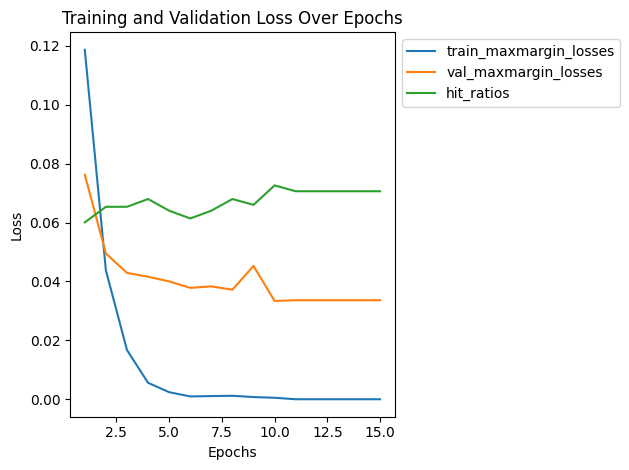

Text(0.5, 1.0, 'Total Hits Over Epochs')

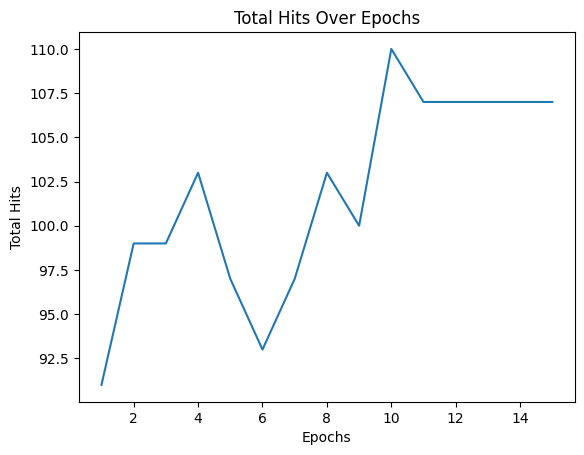

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

##### Overfitting

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=30  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-13-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:09<00:00, 10.34batch/s]


Epoch 1/500, Train Loss: 0.20030988826610074, Val Loss: 0.1972742616245062, Hit Count: 19, Hit Ratio: 1.2541%


Epoch 2/500: 100%|██████████| 101/101 [00:09<00:00, 10.72batch/s]


Epoch 2/500, Train Loss: 0.19810388244614743, Val Loss: 0.19589966469176925, Hit Count: 12, Hit Ratio: 0.7921%


Epoch 3/500: 100%|██████████| 101/101 [00:09<00:00, 10.56batch/s]


...

Epoch 33/500, Train Loss: 0.007394970754290572, Val Loss: 0.25302785262465477, Hit Count: 13, Hit Ratio: 0.8581%


Epoch 34/500: 100%|██████████| 101/101 [00:09<00:00, 10.47batch/s]


Epoch 34/500, Train Loss: 0.00886765384290478, Val Loss: 0.25088500061837754, Hit Count: 13, Hit Ratio: 0.8581%


Epoch 35/500: 100%|██████████| 101/101 [00:09<00:00, 10.57batch/s]


Epoch 35/500, Train Loss: 0.006665707436749841, Val Loss: 0.2368181763161527, Hit Count: 14, Hit Ratio: 0.9241%
Early stopping at epoch 35


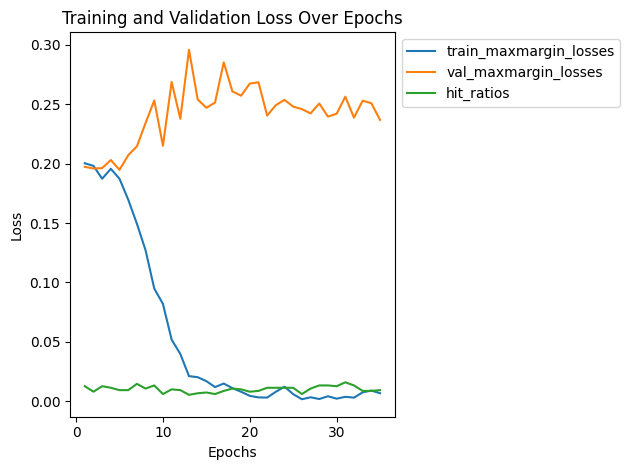

Text(0.5, 1.0, 'Total Hits Over Epochs')

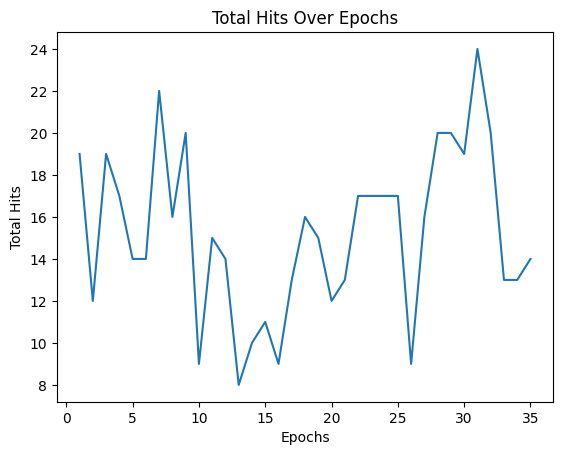

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=30  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:06<00:00, 15.54batch/s]


Epoch 1/500, Train Loss: 0.20012230108870138, Val Loss: 0.1934161465061773, Hit Count: 24, Hit Ratio: 1.5842%


Epoch 2/500: 100%|██████████| 101/101 [00:05<00:00, 17.01batch/s]


Epoch 2/500, Train Loss: 0.18968461394900143, Val Loss: 0.18427046646576117, Hit Count: 23, Hit Ratio: 1.5182%


Epoch 3/500: 100%|██████████| 101/101 [00:06<00:00, 16.34batch/s]


...

Epoch 203/500, Train Loss: 0.0008154386045909164, Val Loss: 0.07622625131049368, Hit Count: 35, Hit Ratio: 2.3102%


Epoch 204/500: 100%|██████████| 101/101 [00:06<00:00, 16.49batch/s]


Epoch 204/500, Train Loss: 0.0016125765914964203, Val Loss: 0.05908500526727426, Hit Count: 54, Hit Ratio: 3.5644%


Epoch 205/500: 100%|██████████| 101/101 [00:06<00:00, 16.01batch/s]


Epoch 205/500, Train Loss: 0.0008806174270587393, Val Loss: 0.05833832133967098, Hit Count: 52, Hit Ratio: 3.4323%
Early stopping at epoch 205


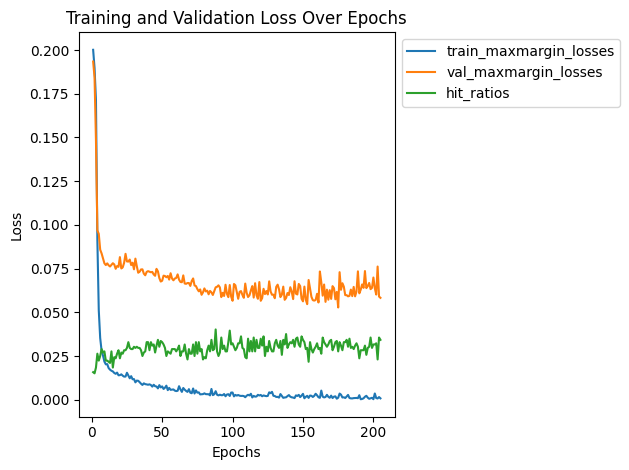

Text(0.5, 1.0, 'Total Hits Over Epochs')

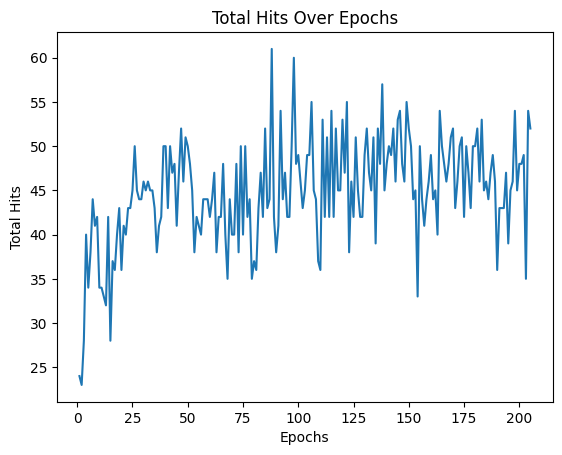

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

##### 300dim user embedding with multiple layers + 1 layer item embedding, reduced dim = 30, lr =0.001

In [ ]:
user_item_model.to(device)

UserItemEmbedding(
  (user_embedding): User_Embedding(
    (user_embedding): Embedding(101, 300)
    (fc): Linear(in_features=300, out_features=30, bias=True)
  )
  (item_embedding): Item_Embedding(
    (audio_embedding): Audio_Embedding(
      (fc): Sequential(
        (0): Linear(in_features=11, out_features=30, bias=True)
        (1): ReLU()
      )
    )
  )
)

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:06<00:00, 16.57batch/s]


Epoch 1/500, Train Loss: 0.20039004426781493, Val Loss: 0.19147799923868464, Hit Count: 31, Hit Ratio: 2.0462%


Epoch 2/500: 100%|██████████| 101/101 [00:06<00:00, 15.59batch/s]


Epoch 2/500, Train Loss: 0.1844342300797453, Val Loss: 0.17651548671840442, Hit Count: 28, Hit Ratio: 1.8482%


Epoch 3/500: 100%|██████████| 101/101 [00:06<00:00, 15.84batch/s]


...

Epoch 55/500, Train Loss: 0.003916600405579746, Val Loss: 0.057922678492446936, Hit Count: 52, Hit Ratio: 3.4323%


Epoch 56/500: 100%|██████████| 101/101 [00:06<00:00, 16.08batch/s]


Epoch 56/500, Train Loss: 0.004213915805857961, Val Loss: 0.06151862660109406, Hit Count: 54, Hit Ratio: 3.5644%


Epoch 57/500: 100%|██████████| 101/101 [00:06<00:00, 16.10batch/s]


Epoch 57/500, Train Loss: 0.004472210081201969, Val Loss: 0.061389535665512085, Hit Count: 57, Hit Ratio: 3.7624%
Early stopping at epoch 57


In [ ]:
torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

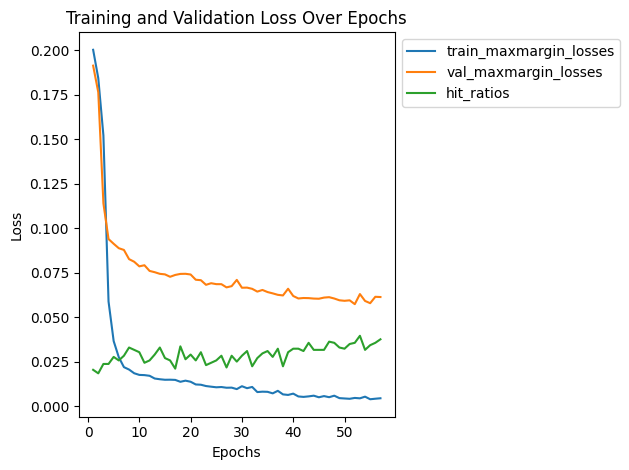

Text(0.5, 1.0, 'Total Hits Over Epochs')

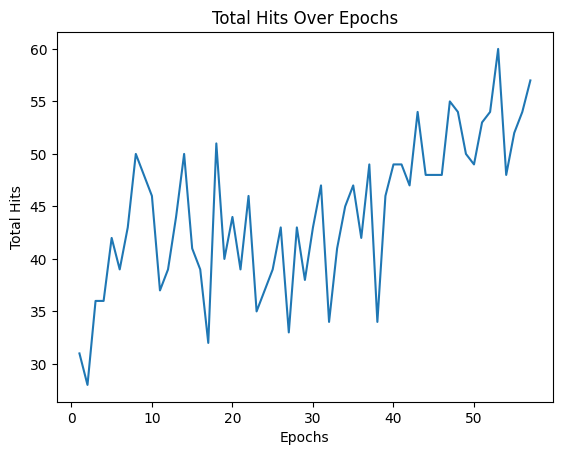

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

##### Less layers in user embedding

In [ ]:
user_item_model.to(device)

UserItemEmbedding(
  (user_embedding): User_Embedding(
    (user_embedding): Embedding(101, 300)
    (fc): Linear(in_features=300, out_features=30, bias=True)
  )
  (item_embedding): Item_Embedding(
    (audio_embedding): Audio_Embedding(
      (fc): Sequential(
        (0): Linear(in_features=11, out_features=30, bias=True)
        (1): ReLU()
      )
    )
  )
)

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:06<00:00, 16.27batch/s]


Epoch 1/500, Train Loss: 0.1998519161255053, Val Loss: 0.19103993438553102, Hit Count: 31, Hit Ratio: 2.0462%


Epoch 2/500: 100%|██████████| 101/101 [00:06<00:00, 15.93batch/s]


Epoch 2/500, Train Loss: 0.18706955797601454, Val Loss: 0.17773812655175086, Hit Count: 29, Hit Ratio: 1.9142%


Epoch 3/500: 100%|██████████| 101/101 [00:06<00:00, 16.17batch/s]


...

Epoch 31/500, Train Loss: 0.007688577664960729, Val Loss: 0.065562284025963, Hit Count: 47, Hit Ratio: 3.1023%


Epoch 32/500: 100%|██████████| 101/101 [00:06<00:00, 15.28batch/s]


Epoch 32/500, Train Loss: 0.008559654863311512, Val Loss: 0.06576223848479809, Hit Count: 49, Hit Ratio: 3.2343%


Epoch 33/500: 100%|██████████| 101/101 [00:06<00:00, 15.68batch/s]


Epoch 33/500, Train Loss: 0.007646697730121046, Val Loss: 0.06720627567703182, Hit Count: 46, Hit Ratio: 3.0363%
Early stopping at epoch 33


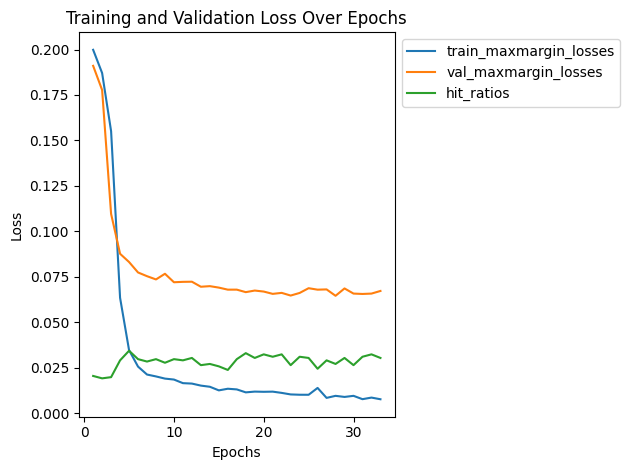

Text(0.5, 1.0, 'Total Hits Over Epochs')

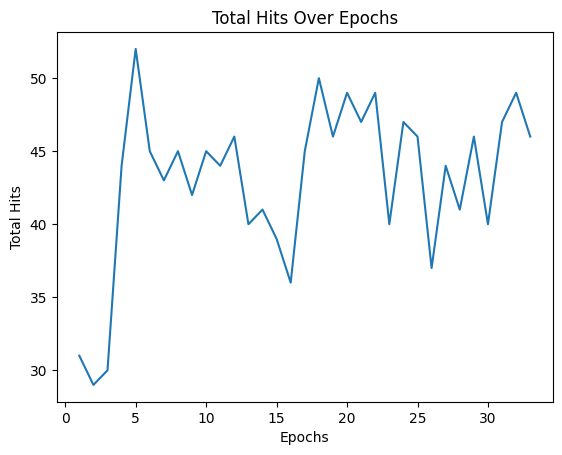

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:05<00:00, 17.38batch/s]


Epoch 1/500, Train Loss: 0.19936750814466192, Val Loss: 0.19239283891597597, Hit Count: 30, Hit Ratio: 1.9802%


Epoch 2/500: 100%|██████████| 101/101 [00:05<00:00, 17.41batch/s]


Epoch 2/500, Train Loss: 0.18602236234905697, Val Loss: 0.18075243973791008, Hit Count: 34, Hit Ratio: 2.2442%


Epoch 3/500: 100%|██████████| 101/101 [00:05<00:00, 17.42batch/s]


...

Epoch 38/500, Train Loss: 0.006962900142194611, Val Loss: 0.06329429441011779, Hit Count: 42, Hit Ratio: 2.7723%


Epoch 39/500: 100%|██████████| 101/101 [00:05<00:00, 17.00batch/s]


Epoch 39/500, Train Loss: 0.007508694609202961, Val Loss: 0.06283144896278287, Hit Count: 47, Hit Ratio: 3.1023%


Epoch 40/500: 100%|██████████| 101/101 [00:05<00:00, 17.24batch/s]


Epoch 40/500, Train Loss: 0.0070941121764665485, Val Loss: 0.06672843990128229, Hit Count: 48, Hit Ratio: 3.1683%
Early stopping at epoch 40


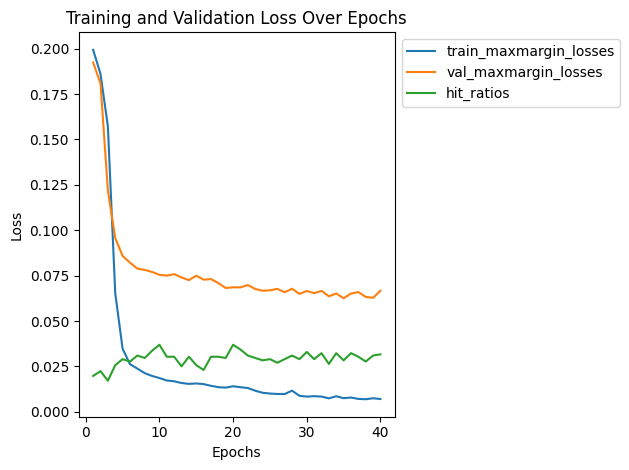

Text(0.5, 1.0, 'Total Hits Over Epochs')

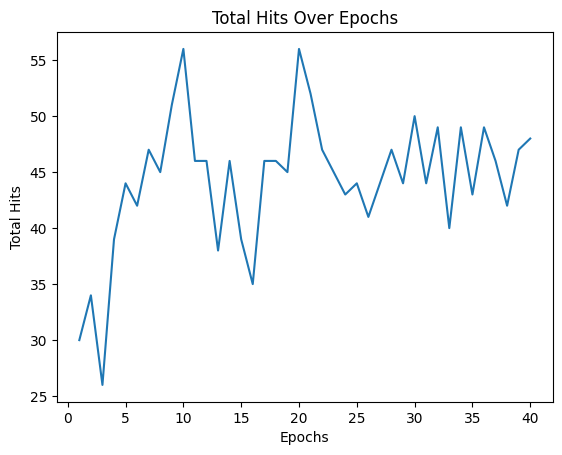

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

##### 300dim user embedding

In [ ]:
user_item_model.to(device)

UserItemEmbedding(
  (user_embedding): User_Embedding(
    (user_embedding): Embedding(101, 300)
    (fc): Linear(in_features=300, out_features=30, bias=True)
  )
  (item_embedding): Item_Embedding(
    (audio_embedding): Audio_Embedding(
      (fc): Sequential(
        (0): Linear(in_features=11, out_features=20, bias=True)
        (1): ReLU()
        (2): Linear(in_features=20, out_features=30, bias=True)
      )
    )
  )
)

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:05<00:00, 17.23batch/s]


Epoch 1/500, Train Loss: 0.2001783430281252, Val Loss: 0.19559315333862115, Hit Count: 32, Hit Ratio: 2.1122%


Epoch 2/500: 100%|██████████| 101/101 [00:05<00:00, 17.14batch/s]


Epoch 2/500, Train Loss: 0.1818764679650269, Val Loss: 0.1434976084545107, Hit Count: 33, Hit Ratio: 2.1782%


Epoch 3/500: 100%|██████████| 101/101 [00:05<00:00, 17.20batch/s]


...

Epoch 29/500, Train Loss: 0.0044061938060982395, Val Loss: 0.06836058878072418, Hit Count: 39, Hit Ratio: 2.5743%


Epoch 30/500: 100%|██████████| 101/101 [00:06<00:00, 16.48batch/s]


Epoch 30/500, Train Loss: 0.004530421780920265, Val Loss: 0.06566657055870141, Hit Count: 40, Hit Ratio: 2.6403%


Epoch 31/500: 100%|██████████| 101/101 [00:06<00:00, 16.42batch/s]


Epoch 31/500, Train Loss: 0.004236998054945823, Val Loss: 0.06664602274056708, Hit Count: 40, Hit Ratio: 2.6403%
Early stopping at epoch 31


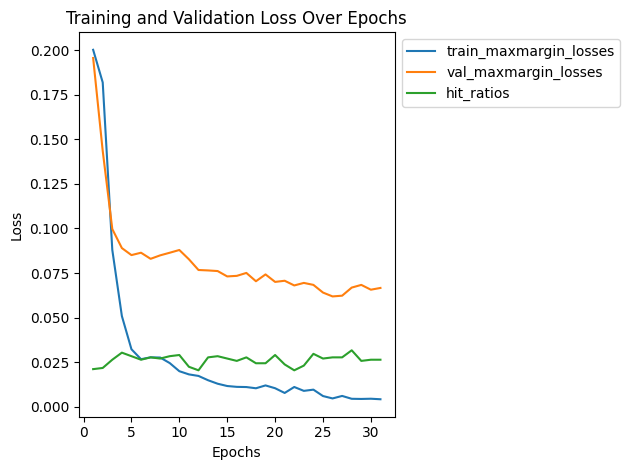

Text(0.5, 1.0, 'Total Hits Over Epochs')

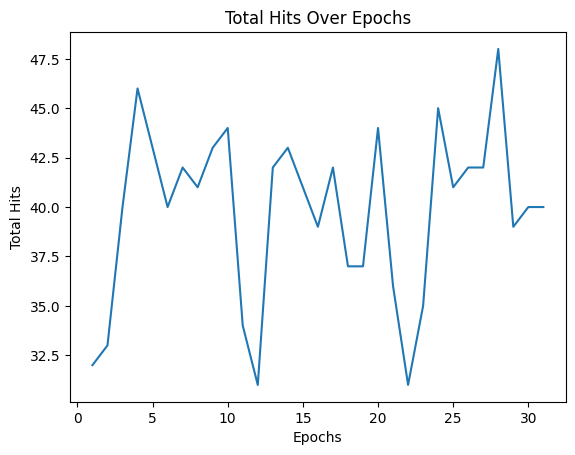

In [ ]:
# Convert tensors to CPU and numpy arrays
# train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
# val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

##### 한번 더돌리기

In [ ]:
#device = 'cpu'
user_item_model.to(device)

UserItemEmbedding(
  (user_embedding): User_Embedding(
    (user_embedding): Embedding(101, 100)
    (fc): Linear(in_features=100, out_features=30, bias=True)
  )
  (item_embedding): Item_Embedding(
    (audio_embedding): Audio_Embedding(
      (fc): Sequential(
        (0): Linear(in_features=11, out_features=20, bias=True)
        (1): ReLU()
        (2): Linear(in_features=20, out_features=30, bias=True)
      )
    )
  )
)

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:08<00:00, 12.58batch/s]


Epoch 1/500, Train Loss: 0.19997930718530524, Val Loss: 0.19687158488991238, Hit Count: 28, Hit Ratio: 1.8482%


Epoch 2/500: 100%|██████████| 101/101 [00:07<00:00, 13.37batch/s]


Epoch 2/500, Train Loss: 0.19277577257097359, Val Loss: 0.1800213129361077, Hit Count: 31, Hit Ratio: 2.0462%


Epoch 3/500: 100%|██████████| 101/101 [00:07<00:00, 13.39batch/s]


...

Epoch 23/500, Train Loss: 0.00933462005145479, Val Loss: 0.07333775189253364, Hit Count: 39, Hit Ratio: 2.5743%


Epoch 24/500: 100%|██████████| 101/101 [00:06<00:00, 16.79batch/s]


Epoch 24/500, Train Loss: 0.008942605134579215, Val Loss: 0.07374253894875546, Hit Count: 40, Hit Ratio: 2.6403%


Epoch 25/500: 100%|██████████| 101/101 [00:06<00:00, 16.47batch/s]


Epoch 25/500, Train Loss: 0.007694342348835256, Val Loss: 0.07375493927831107, Hit Count: 36, Hit Ratio: 2.3762%
Early stopping at epoch 25


##### Best Results so far

In [ ]:
#device = 'cpu'
user_item_model.to(device)

UserItemEmbedding(
  (user_embedding): User_Embedding(
    (user_embedding): Embedding(101, 100)
    (fc): Linear(in_features=100, out_features=30, bias=True)
  )
  (item_embedding): Item_Embedding(
    (audio_embedding): Audio_Embedding(
      (fc): Sequential(
        (0): Linear(in_features=11, out_features=20, bias=True)
        (1): ReLU()
        (2): Linear(in_features=20, out_features=30, bias=True)
      )
    )
  )
)

In [ ]:
#Top 100 + 10k + Only AUDIO + Hit Rate Codes Updated
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_counts, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500:   0%|          | 0/101 [00:00<?, ?batch/s]<ipython-input-10-5db36fc5addc>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'track_embeddings': torch.tensor(np.array(I_plus_batch['track_embeddings']).tolist(), dtype=torch.float32),
Epoch 1/500: 100%|██████████| 101/101 [00:05<00:00, 17.81batch/s]


Epoch 1/500, Train Loss: 0.19951995071208123, Val Loss: 0.19670283307533454, Hit Count: 30, Hit Ratio: 1.9801980198019802


Epoch 2/500: 100%|██████████| 101/101 [00:06<00:00, 16.76batch/s]


Epoch 2/500, Train Loss: 0.18863573862184393, Val Loss: 0.17499626789352682, Hit Count: 34, Hit Ratio: 2.2442244224422443


Epoch 3/500: 100%|██████████| 101/101 [00:05<00:00, 17.15batch/s]


...

Epoch 34/500, Train Loss: 0.013717161805027783, Val Loss: 0.0729510648784661, Hit Count: 64, Hit Ratio: 4.224422442244224


Epoch 35/500: 100%|██████████| 101/101 [00:05<00:00, 17.02batch/s]


Epoch 35/500, Train Loss: 0.0125284346908626, Val Loss: 0.07225210215933252, Hit Count: 60, Hit Ratio: 3.9603960396039604


Epoch 36/500: 100%|██████████| 101/101 [00:05<00:00, 17.28batch/s]


Epoch 36/500, Train Loss: 0.0135106227480539, Val Loss: 0.07315325379224107, Hit Count: 58, Hit Ratio: 3.8283828382838285
Early stopping at epoch 36


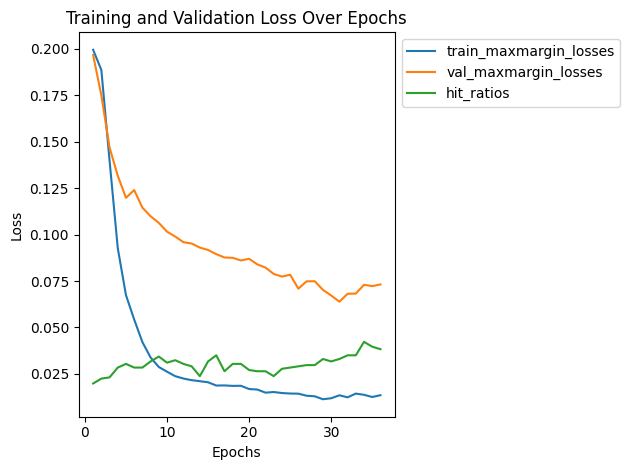

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')



plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


Text(0.5, 1.0, 'Total Hits Over Epochs')

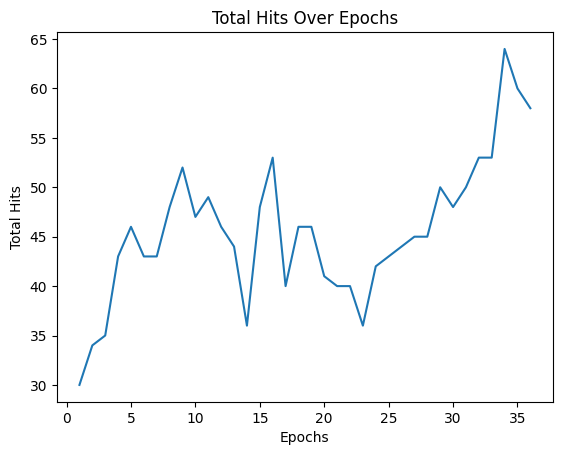

In [ ]:
plt.plot(range(1, len(hit_counts)+1),hit_counts, label='hit_ratios')

plt.xlabel('Epochs')
plt.ylabel('Total Hits')
plt.title('Total Hits Over Epochs')

In [ ]:
#Top 100 + 10k + Only AUDIO
train_losses, val_losses, train_maxmargin_losses, val_maxmargin_losses, hit_ratios = training_loop(
    n_epochs=500,  # Number of epochs
    optimizer=torch.optim.Adam(user_item_model.parameters(), lr=0.001),
    model=user_item_model,
    loss_fn= MaxMarginLoss(margin=0.2),
    recon_loss_fn=nn.MSELoss(),
    train_loader=train_loader,
    val_loader=val_loader,  # Validation loader
    patience=5  # Stop if no improvement for 5 epochs
)

#torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

Epoch 1/500: 100%|██████████| 101/101 [00:05<00:00, 17.17batch/s]


Epoch 1/500, Train Loss: 0.1902065055795235, Val Loss: 0.17164417459528045, Hit Ratio: 0.0


Epoch 2/500: 100%|██████████| 101/101 [00:05<00:00, 17.27batch/s]


Epoch 2/500, Train Loss: 0.12920968127575252, Val Loss: 0.1118679690442168, Hit Ratio: 0.0


Epoch 3/500: 100%|██████████| 101/101 [00:05<00:00, 17.21batch/s]


...

Epoch 26/500, Train Loss: 0.006501672503602977, Val Loss: 0.06705077767077058, Hit Ratio: 0.0


Epoch 27/500: 100%|██████████| 101/101 [00:05<00:00, 17.21batch/s]


Epoch 27/500, Train Loss: 0.0046083268681817715, Val Loss: 0.060242642915927534, Hit Ratio: 0.0


Epoch 28/500: 100%|██████████| 101/101 [00:05<00:00, 16.96batch/s]


Epoch 28/500, Train Loss: 0.003553796854644719, Val Loss: 0.0607293428170799, Hit Ratio: 0.0
Early stopping at epoch 28


In [ ]:
torch.save(user_item_model.state_dict(), 'user_item_model_ver8_10k_epoch500.pth')

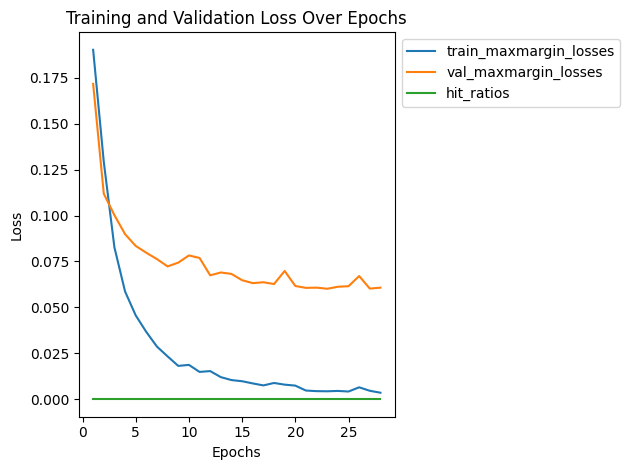

In [ ]:
# Convert tensors to CPU and numpy arrays
train_maxmargin_losses = [loss.cpu().item() for loss in train_maxmargin_losses]
val_maxmargin_losses = [loss.cpu().item() for loss in val_maxmargin_losses]



# Plotting
plt.plot(range(1, len(train_maxmargin_losses) + 1), train_maxmargin_losses, label='train_maxmargin_losses')
plt.plot(range(1, len(val_maxmargin_losses) + 1), val_maxmargin_losses, label='val_maxmargin_losses')
plt.plot(range(1, len(hit_ratios)+1),hit_ratios, label='hit_ratios')


plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


In [ ]:
# Assuming 'model' is the trained UserItemEmbedding model
user_embeddings = user_item_model.user_embedding.user_embedding.weight.data

# Print shape and first few embeddings for verification
print("Embedding Shape:", user_embeddings.shape)
print("First Embedding:", user_embeddings[0])


Embedding Shape: torch.Size([101, 100])
First Embedding: tensor([-1.2937, -0.3306,  0.6089, -0.3057,  1.1147, -1.5875, -0.5308,  0.3759,
         0.3760,  1.3303,  0.7646,  0.7132,  0.3501,  0.9008, -2.8829, -0.1007,
         0.8463, -0.0675,  0.1566,  0.3684,  1.0464, -1.2333,  1.1498,  0.6820,
        -0.0147, -0.5148, -0.9172,  0.2593,  0.8957, -0.3168,  0.5340,  0.4403,
         0.9831,  0.3962,  0.1715, -0.2243, -0.8719, -0.0462,  0.9975, -0.8920,
         1.5270,  0.6084, -0.8888,  0.8988,  0.9243,  1.0623, -0.4337, -0.8947,
        -0.3304,  0.6280,  1.4170, -0.6757,  0.0309,  0.5878,  1.4408,  0.2297,
        -1.6263, -0.0351, -0.7290,  0.5932,  0.1035,  1.2913,  0.0264,  1.7578,
        -0.7780,  0.2405,  0.0658,  0.9935, -0.6737,  1.3875, -0.8706, -0.2180,
        -0.3747,  1.5761, -0.7149, -0.8842,  1.9680, -0.5046,  1.2638, -0.1984,
         0.1156,  1.4897,  1.8876,  0.2492,  1.3027,  1.2305,  0.0531, -0.4975,
        -0.0654, -0.4382, -0.7495,  0.7407, -2.4228, -0.5679, -

In [ ]:
loaded_model.user_embedding.user_embedding.weight.data[0]

tensor([-1.2937, -0.3306,  0.6089, -0.3057,  1.1147, -1.5875, -0.5308,  0.3759,
         0.3760,  1.3303,  0.7646,  0.7132,  0.3501,  0.9008, -2.8829, -0.1007,
         0.8463, -0.0675,  0.1566,  0.3684,  1.0464, -1.2333,  1.1498,  0.6820,
        -0.0147, -0.5148, -0.9172,  0.2593,  0.8957, -0.3168,  0.5340,  0.4403,
         0.9831,  0.3962,  0.1715, -0.2243, -0.8719, -0.0462,  0.9975, -0.8920,
         1.5270,  0.6084, -0.8888,  0.8988,  0.9243,  1.0623, -0.4337, -0.8947,
        -0.3304,  0.6280,  1.4170, -0.6757,  0.0309,  0.5878,  1.4408,  0.2297,
        -1.6263, -0.0351, -0.7290,  0.5932,  0.1035,  1.2913,  0.0264,  1.7578,
        -0.7780,  0.2405,  0.0658,  0.9935, -0.6737,  1.3875, -0.8706, -0.2180,
        -0.3747,  1.5761, -0.7149, -0.8842,  1.9680, -0.5046,  1.2638, -0.1984,
         0.1156,  1.4897,  1.8876,  0.2492,  1.3027,  1.2305,  0.0531, -0.4975,
        -0.0654, -0.4382, -0.7495,  0.7407, -2.4228, -0.5679, -0.6509, -0.7758,
         0.8487,  0.0829, -2.3797,  0.85